# 1. Data Loading

In [11]:
import sys
!{sys.executable} -m pip install imbalanced-learn optuna jinja2


[notice] A new release of pip is available: 25.2 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [12]:
import warnings
warnings.filterwarnings('ignore')

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.impute import SimpleImputer
import jinja2 
import sys
from sklearn.experimental import enable_iterative_imputer
from sklearn.ensemble import GradientBoostingClassifier, GradientBoostingRegressor
from sklearn.metrics import accuracy_score, precision_score, recall_score,f1_score, matthews_corrcoef, classification_report, ConfusionMatrixDisplay, roc_auc_score
from sklearn.model_selection import cross_val_score, StratifiedKFold

from imblearn.pipeline import Pipeline as ImbPipeline
from imblearn.over_sampling import SMOTE, RandomOverSampler, ADASYN
from imblearn.under_sampling import RandomUnderSampler, TomekLinks
from imblearn.combine import SMOTEENN, SMOTETomek

from sklearn.impute import IterativeImputer

import optuna
from optuna.pruners import MedianPruner
from optuna.samplers import TPESampler
from sklearn.preprocessing import StandardScaler

ruta_raiz = os.path.abspath('..')
if ruta_raiz not in sys.path:
    sys.path.append(ruta_raiz)

%load_ext autoreload
%autoreload 2
from Data_preprocesing.IQRCapper import IQRCapper

optuna.logging.set_verbosity(optuna.logging.WARNING)

RANDOM_STATE = 42


The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [13]:
X_train = pd.read_csv("../Train_test_split/X_train.csv")
X_test  = pd.read_csv("../Train_test_split/X_test.csv")
y_train = pd.read_csv("../Train_test_split/y_train.csv").squeeze()
y_test  = pd.read_csv("../Train_test_split/y_test.csv").squeeze()

target_folder = '../comparations'

def save_experiment(model_name, imbalance_method, accuracy, precision, recall, f1, roc_auc):
    new_result = {
        'Model': [model_name],
        'Imbalance_Method': [imbalance_method],
        'Accuracy': [round(accuracy, 4)],
        'Precision': [round(precision, 4)],
        'Recall': [round(recall, 4)],
        'F1_Score': [round(f1, 4)],
        'ROC_AUC': [round(roc_auc, 4)]
    }
    df_new = pd.DataFrame(new_result)
    
    # Point the file to inside the folder
    csv_file = f'{target_folder}/imbalance_results.csv'
    
    if os.path.exists(csv_file):
        df_new.to_csv(csv_file, mode='a', header=False, index=False)
    else:
        df_new.to_csv(csv_file, index=False)
        
    print(f"✅ Success! Results for {model_name} + {imbalance_method} saved in the '{target_folder}' folder.")


# 2. Class labels

In [14]:
class_labels = {0: 'Segment 0', 1: 'Segment 1', 2: 'Segment 2', 3: 'Segment 3'}


# 3.Imbalance Mitigation


In [15]:

def evaluate_model(model, X_tr, y_tr, X_te, y_te, name):
    model.fit(X_tr, y_tr)
    y_pred = model.predict(X_te)
    if hasattr(model, "predict_proba"):
        y_proba = model.predict_proba(X_te)
        roc_auc = round(roc_auc_score(y_te, y_proba, multi_class='ovr', average='macro'), 4)
    else:
        roc_auc = "N/A" 
        
    return {
        'Strategy': name,
        'Accuracy':  round(accuracy_score(y_te, y_pred), 4),
        'Precision': round(precision_score(y_te, y_pred, average='macro', zero_division=0), 4),
        'Recall':    round(recall_score(y_te, y_pred, average='macro', zero_division=0), 4),
        'F1 (macro)':round(f1_score(y_te, y_pred, average='macro', zero_division=0), 4),
        'ROC_AUC':   roc_auc
    }


base_gb = GradientBoostingClassifier(n_estimators=100, random_state=RANDOM_STATE)


strategies = [
    ('No Resampling (Baseline)',
     ImbPipeline([
         ('capping_outliers', IQRCapper(factor=1.5)),
        ('imputacion', SimpleImputer(strategy='mean')), 
        ('scaler', StandardScaler()),
         ('clf', GradientBoostingClassifier(n_estimators=100, random_state=RANDOM_STATE)),
     ])),
    
    ('RandomOverSampler',
     ImbPipeline([
         ('capping_outliers', IQRCapper(factor=1.5)),
        ('imputacion', SimpleImputer(strategy='mean')),
        ('scaler', StandardScaler()),
         ('sampler', RandomOverSampler(random_state=RANDOM_STATE)),
         ('clf',     GradientBoostingClassifier(n_estimators=100, random_state=RANDOM_STATE))
     ])),

    ('SMOTE',
     ImbPipeline([
         ('capping_outliers', IQRCapper(factor=1.5)),
         ('imputacion', SimpleImputer(strategy='mean')),
         ('scaler', StandardScaler()),
         ('sampler', SMOTE(random_state=RANDOM_STATE, k_neighbors=5)),
         ('clf',     GradientBoostingClassifier(n_estimators=100, random_state=RANDOM_STATE))
     ])),

    ('RandomUnderSampler',
     ImbPipeline([
         ('capping_outliers', IQRCapper(factor=1.5)),
         ('imputacion', SimpleImputer(strategy='mean')),
         ('scaler', StandardScaler()),
         ('sampler', RandomUnderSampler(random_state=RANDOM_STATE)),
         ('clf',     GradientBoostingClassifier(n_estimators=100, random_state=RANDOM_STATE))
     ])),

    ('SMOTEENN',
     ImbPipeline([
         ('capping_outliers', IQRCapper(factor=1.5)),
         ('imputacion', SimpleImputer(strategy= 'mean')),
         ('scaler', StandardScaler()),
         ('sampler', SMOTEENN(random_state=RANDOM_STATE)),
         ('clf',     GradientBoostingClassifier(n_estimators=100, random_state=RANDOM_STATE))
     ])),

    ('Adasyn',
     ImbPipeline([
         ('capping_outliers', IQRCapper(factor=1.5)),
         ('imputacion', SimpleImputer(strategy='mean')),
         ('scaler', StandardScaler()),
         ('sampler', ADASYN(random_state=RANDOM_STATE)),
         ('clf',     GradientBoostingClassifier(n_estimators=100, random_state=RANDOM_STATE))
     ])),

     ('Tomek Links',
     ImbPipeline([
         ('capping_outliers', IQRCapper(factor=1.5)),
         ('imputacion', SimpleImputer(strategy='mean')),
         ('scaler', StandardScaler()),
         ('sampler', TomekLinks()),
         ('clf',     GradientBoostingClassifier(n_estimators=100, random_state=RANDOM_STATE))
     ])),



     ('SMOTETomek',
     ImbPipeline([
         ('capping_outliers', IQRCapper(factor=1.5)),
         ('imputacion', SimpleImputer(strategy='mean')),
         ('scaler', StandardScaler()),
         ('sampler', SMOTETomek(random_state=RANDOM_STATE)),
         ('clf',     GradientBoostingClassifier(n_estimators=100, random_state=RANDOM_STATE))
     ])), 

]

results = []
for name, pipeline in strategies:
    print(f'Training: {name}...', end=' ')
    res = evaluate_model(pipeline, X_train, y_train, X_test, y_test, name)
    results.append(res)
    print(f'F1={res["F1 (macro)"]:.4f}')


results_df = pd.DataFrame(results)
print('\nDone!')

'''save_experiment(
        model_name="GradientBoosting",
        imbalance_method=res['Strategy'],
        accuracy=res['Accuracy'],
        precision=res['Precision'],
        recall=res['Recall'],
        f1=res['F1 (macro)'],
        roc_auc=res['ROC_AUC']
    )'''
#El mejor resultado es el de No Resampling, GradientBoosting funciona muy bien con datasets
#Medianamente desbalanceados, por ello al forzar un balanceo antinatura, los resultados pueden
#Empeorar. Con RandomOverSampler al copiar columnas iguales constantemente existe grandes posibilidades
#De sobre ajuste. SMOTE lo que hace es fijarse en vecinos y crear datos nuevos en base a ello, por eso 
#Existen las posibilidades de creacion de data que pertenezca a otra clase. En RandomUnderSampling
#Puede eliminar datos reales e importantes para el modelo para aprender mejor.Smoteen infla la clase 
#Mayoritaria y luego hace una limpieza, tanto de puntos reales como sinteticos, eso hace que puede
#Que puntos diferentes a sus vecinos pero reales desaparezcan.SmoteTomek, hace tambien la inflacion de
#clases, lo que hace es busca los links tomek, que son links que por lo general suponen que estan en 
#Una zona de confusion, entonces lo que hace es eliminar ambos puntos o unicamente los de la clase 
#Mayoritaria, este tipo de mitigation es mas precisa, mas analitica por lo que ni elimina agresivamente
#Ni se inventa unicamente datos, se basa en la confusion para eliminar





#GradientBoosting funciona bien con datasets medianamente desbalanceados, principalmente porque 
#Es un modelo de secuencialidad, esto que significa? que va creando arbolitos poco a poco, empieza
#Por los casos mas faciles por asi decirlo, por ello empieza con la parte que tiene mas % haciendo 
#Que salgan errores no en el modelo en general ni en la parte de alto porcentaje, si no que en la parte
#minoritaria, haciendo que el modelo diga "Anda hay un error aqui, me voy a fijar mas", por lo que en 
#La siguiente iteracion se fija un poquito mas en la parte minoritaria y así consecutivamente.
#Si fuese un caso de desbalanceo extremo, el modelo trataria la clase minoritaria como outliers

Training: No Resampling (Baseline)... F1=0.7628
Training: RandomOverSampler... F1=0.7526
Training: SMOTE... F1=0.7500
Training: RandomUnderSampler... F1=0.7493
Training: SMOTEENN... F1=0.7081
Training: Adasyn... F1=0.7456
Training: Tomek Links... F1=0.7583
Training: SMOTETomek... F1=0.7517

Done!


'save_experiment(\n        model_name="GradientBoosting",\n        imbalance_method=res[\'Strategy\'],\n        accuracy=res[\'Accuracy\'],\n        precision=res[\'Precision\'],\n        recall=res[\'Recall\'],\n        f1=res[\'F1 (macro)\'],\n        roc_auc=res[\'ROC_AUC\']\n    )'

In [16]:
metric_cols = ['Accuracy', 'Precision', 'Recall', 'F1 (macro)', 'ROC_AUC']
styled = results_df.style \
    .highlight_max(subset=metric_cols, color='black') \
    .set_caption('Gradient Boosting Performance by Imbalance Strategy (default hyperparameters)') \
    .format({c: '{:.4f}' for c in metric_cols})
styled

,Strategy,Accuracy,Precision,Recall,F1 (macro),ROC_AUC
0,No Resampling (Baseline),0.7601,0.7744,0.7534,0.7628,0.9171
1,RandomOverSampler,0.7398,0.7520,0.7589,0.7526,0.9139
2,SMOTE,0.7411,0.7488,0.7545,0.7500,0.9132
3,RandomUnderSampler,0.7361,0.7468,0.7576,0.7493,0.9122
4,SMOTEENN,0.6871,0.7097,0.7354,0.7081,0.9009
5,Adasyn,0.7390,0.7422,0.7540,0.7456,0.9124
6,Tomek Links,0.7567,0.7683,0.7520,0.7583,0.9162
7,SMOTETomek,0.7425,0.7503,0.7567,0.7517,0.9131


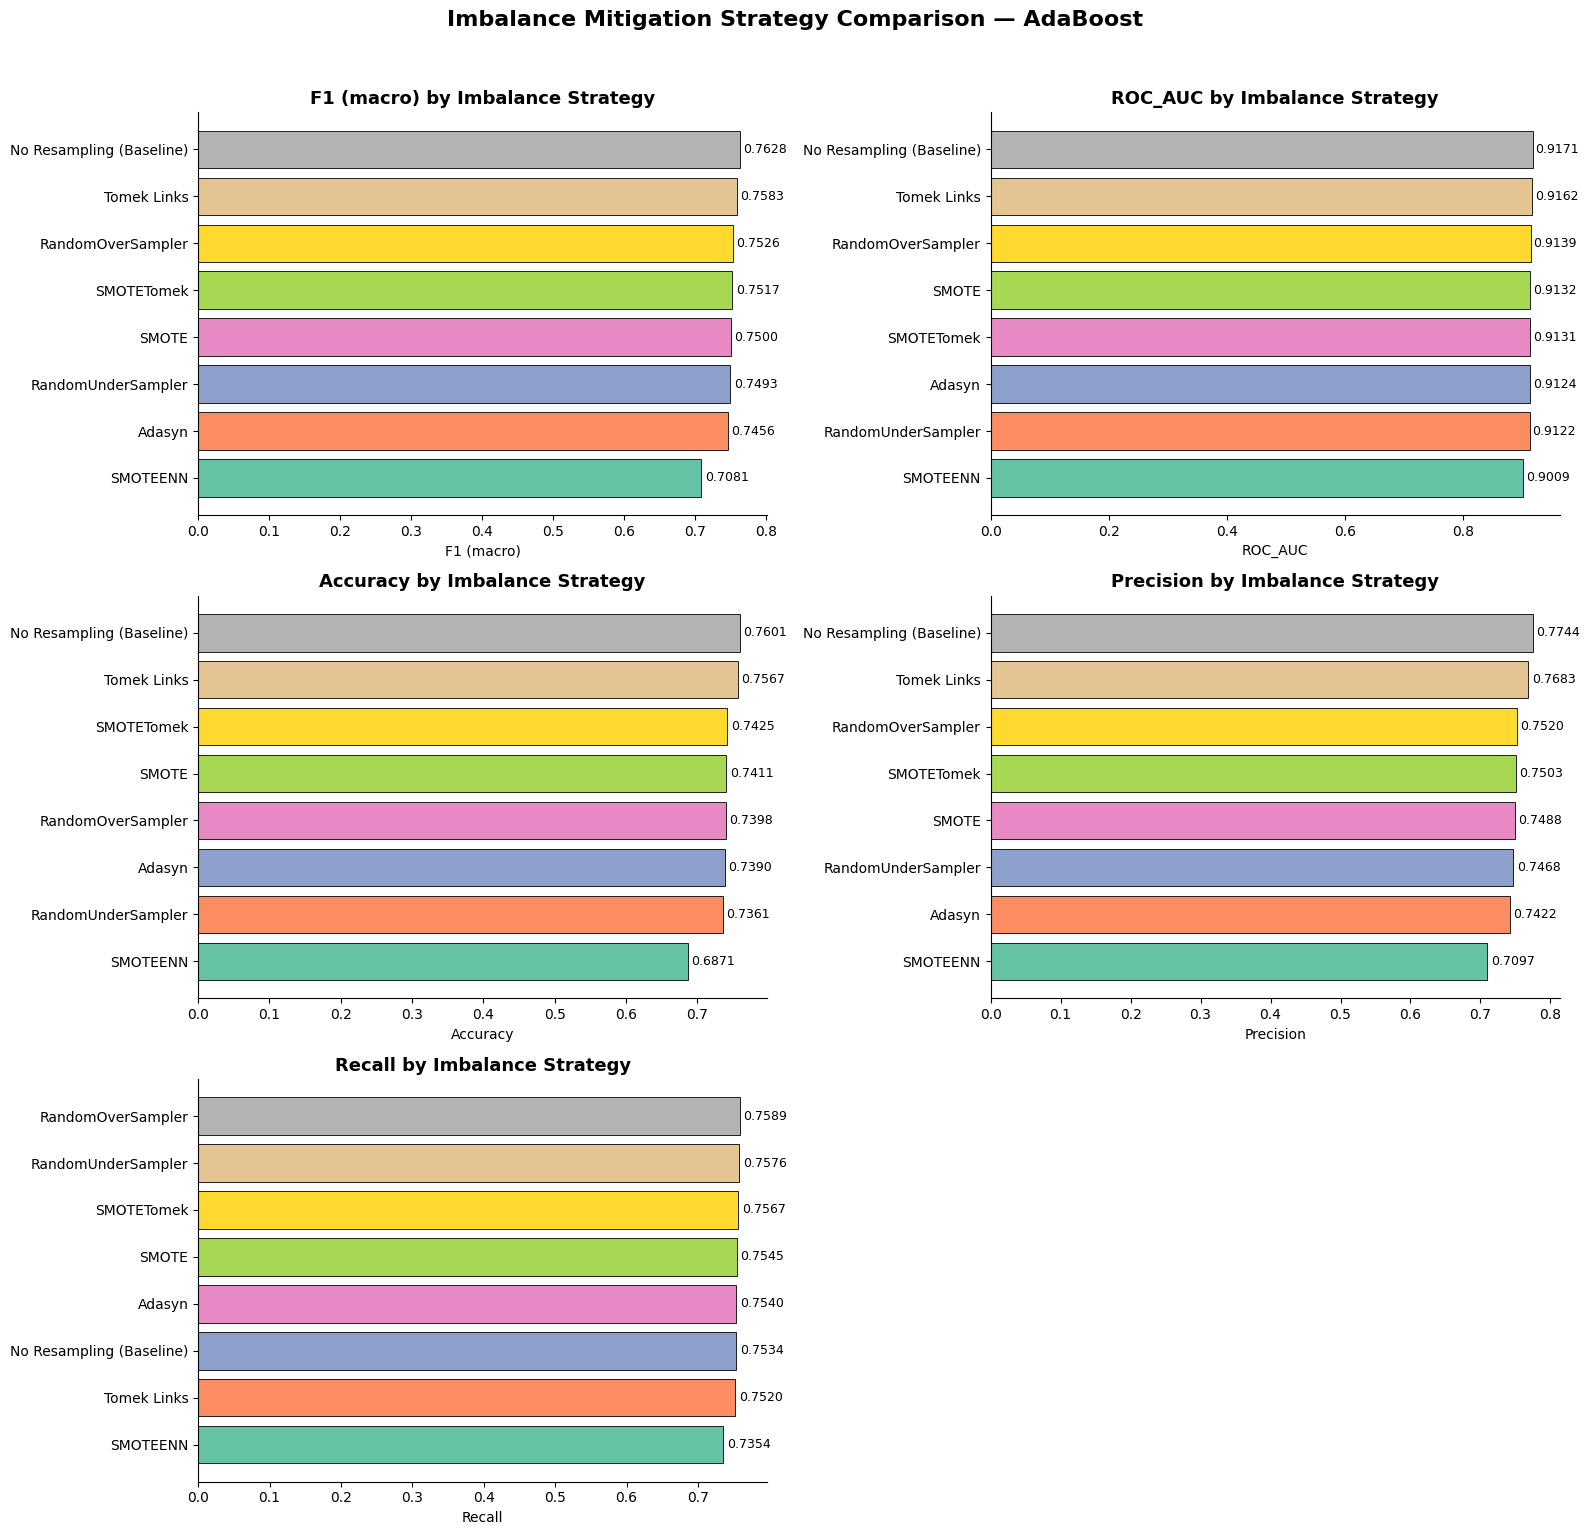

In [17]:
# 1. Ajustamos a una cuadrícula de 3 filas y 2 columnas (para hasta 6 métricas)
fig, axes = plt.subplots(3, 2, figsize=(16, 15)) 

# Aplanamos la matriz de ejes para iterar fácilmente sobre ella
axes_flat = axes.flatten()

metrics_to_plot = ['F1 (macro)', 'ROC_AUC', 'Accuracy', 'Precision', 'Recall']
palette = sns.color_palette('Set2', len(results_df))

for i, metric in enumerate(metrics_to_plot):
    ax = axes_flat[i]
    sorted_df = results_df.sort_values(metric, ascending=True)
    
    bars = ax.barh(sorted_df['Strategy'], sorted_df[metric], color=palette, edgecolor='black', linewidth=0.6)
    
    ax.set_title(f'{metric} by Imbalance Strategy', fontsize=13, fontweight='bold')
    ax.set_xlabel(metric)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    
    # Añadir etiquetas de valor
    for bar, val in zip(bars, sorted_df[metric]):
        ax.text(val + 0.005, bar.get_y() + bar.get_height()/2,
                f'{val:.4f}', va='center', fontsize=9)

# 2. Ocultar el último gráfico (el 6º) si queda vacío
if len(axes_flat) > len(metrics_to_plot):
    axes_flat[-1].set_axis_off()

plt.suptitle('Imbalance Mitigation Strategy Comparison — AdaBoost', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

# 5.Hyperparameter tuning with optuna


In [18]:
best_row = results_df.loc[results_df['F1 (macro)'].idxmax()]
best_strategy_name = best_row['Strategy']
print(f'Best imbalance strategy: "{best_strategy_name}" (F1={best_row["F1 (macro)"]:.4f})')
print('\nThis strategy will be used inside the Optuna objective function.')

#La mejor es la GB sin mitigar, como se puede apreciar siendo la mejor en 4 de las 5 metricas de 
#Performance

Best imbalance strategy: "No Resampling (Baseline)" (F1=0.7628)

This strategy will be used inside the Optuna objective function.


In [ ]:
from sklearn.ensemble import HistGradientBoostingClassifier
from sklearn.model_selection import train_test_split
from sklearn.utils.class_weight import compute_sample_weight
import optuna
import numpy as np

def make_sampler(strategy_name, random_state=RANDOM_STATE):
    """Returns the imblearn sampler for the given strategy name."""
    mapping = {
        'RandomOverSampler': RandomOverSampler(random_state=random_state),
        'SMOTE':             SMOTE(random_state=random_state),
        'RandomUnderSampler':RandomUnderSampler(random_state=random_state),
        'SMOTEENN':          SMOTEENN(random_state=random_state),
        'SMOTETomek':        SMOTETomek(random_state=random_state),
    }
    return mapping.get(strategy_name, None)

def objective(trial):
    """Optuna objective: maximize macro F1 of HistGradientBoostingClassifier."""
    # --- Espacio de hiperparámetros rápido ---
    params = {
        'max_iter':          trial.suggest_int('max_iter', 50, 400),
        'learning_rate':     trial.suggest_float('learning_rate', 0.01, 0.3, log=True),
        'max_depth':         trial.suggest_int('max_depth', 2, 7),
        'min_samples_leaf':  trial.suggest_int('min_samples_leaf', 1, 20),
        'l2_regularization': trial.suggest_float('l2_regularization', 1e-8, 10.0, log=True),
        'random_state':      RANDOM_STATE
    }

    # Usamos el algoritmo súper rápido
    clf = HistGradientBoostingClassifier(**params)

    # Wrap in imblearn pipeline if resampling needed
    sampler = make_sampler(best_strategy_name)
    if sampler is not None:
        model = ImbPipeline([
         ('capping_outliers', IQRCapper(factor=1.5)),
         ('imputacion', SimpleImputer(strategy='mean')),
         ('sampler', sampler), ('clf', clf)])
    else:
        model = clf

    # Train/Val split 80/20 (esto elimina el bucle lento de 3 Folds)
    X_tr, X_val, y_tr, y_val = train_test_split(
        X_train, y_train, test_size=0.2, stratify=y_train, random_state=RANDOM_STATE
    )

    if best_strategy_name == 'class_weight=balanced':
        sw = compute_sample_weight('balanced', y_tr)
        if sampler is not None:
            model.fit(X_tr, y_tr, clf__sample_weight=sw)
        else:
            model.fit(X_tr, y_tr, sample_weight=sw)
    else:
        model.fit(X_tr, y_tr)

    # Evaluación
    y_pred = model.predict(X_val)
    f1 = f1_score(y_val, y_pred, average='macro', zero_division=0)

    # Reportar el valor (si el F1 es malísimo desde el inicio, Optuna lo notará)
    trial.report(f1, 0)
    if trial.should_prune():
        raise optuna.exceptions.TrialPruned()

    return f1

print('Objective function defined using GradientBoostingClassifier.')

Objective function defined using HistGradientBoostingClassifier.


In [20]:
study = optuna.create_study(
    direction='maximize',
    sampler=TPESampler(seed=RANDOM_STATE),
    pruner=MedianPruner(n_startup_trials=5, n_warmup_steps=1)
)

print('Starting Optuna optimization (30 trials)...')
print('Pruner: MedianPruner — unpromising trials will be cut early.\n')

study.optimize(objective, n_trials=30, show_progress_bar=True)

print(f'\nOptimization complete!')
print(f'Best trial:  #{study.best_trial.number}')
print(f'Best CV F1:  {study.best_value:.4f}')
print(f'Best params: {study.best_params}')

Starting Optuna optimization (30 trials)...
Pruner: MedianPruner — unpromising trials will be cut early.



Best trial: 26. Best value: 0.768587: 100%|██████████| 30/30 [01:02<00:00,  2.08s/it]


Optimization complete!
Best trial:  #26
Best CV F1:  0.7686
Best params: {'max_iter': 286, 'learning_rate': 0.0342575800760399, 'max_depth': 4, 'min_samples_leaf': 10, 'l2_regularization': 0.5317639744099767}


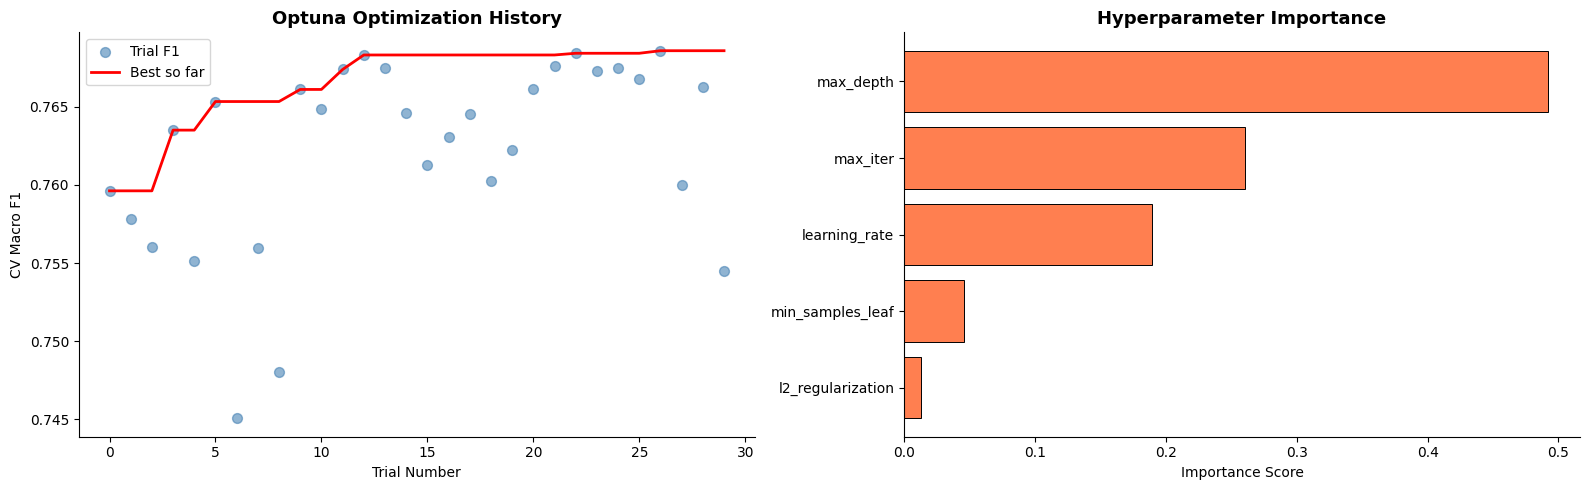


Completed trials: 30 | Pruned trials: 0
Pruning rate: 0.0% — MedianPruner saved computation time.


In [21]:
# --- Plot optimization history ---
completed = [t for t in study.trials if t.state == optuna.trial.TrialState.COMPLETE]
pruned    = [t for t in study.trials if t.state == optuna.trial.TrialState.PRUNED]

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Optimization history
trial_nums = [t.number for t in completed]
trial_vals = [t.value for t in completed]
best_so_far = [max(trial_vals[:i+1]) for i in range(len(trial_vals))]

axes[0].scatter(trial_nums, trial_vals, alpha=0.6, color='steelblue', s=50, label='Trial F1')
axes[0].plot(trial_nums, best_so_far, color='red', linewidth=2, label='Best so far')
pruned_nums = [t.number for t in pruned]
if pruned_nums:
    axes[0].axvline(x=pruned_nums[0], color='grey', linestyle='--', alpha=0.4, label='Pruned trials')
    for pn in pruned_nums[1:]:
        axes[0].axvline(x=pn, color='grey', linestyle='--', alpha=0.4)
axes[0].set_title('Optuna Optimization History', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Trial Number')
axes[0].set_ylabel('CV Macro F1')
axes[0].legend()
axes[0].spines['top'].set_visible(False)
axes[0].spines['right'].set_visible(False)

# Parameter importance (top 6)
importances = optuna.importance.get_param_importances(study)
imp_df = pd.DataFrame(list(importances.items()), columns=['Parameter', 'Importance']).head(6)
imp_df = imp_df.sort_values('Importance')
axes[1].barh(imp_df['Parameter'], imp_df['Importance'], color='coral', edgecolor='black', linewidth=0.7)
axes[1].set_title('Hyperparameter Importance', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Importance Score')
axes[1].spines['top'].set_visible(False)
axes[1].spines['right'].set_visible(False)

plt.tight_layout()
plt.show()

print(f'\nCompleted trials: {len(completed)} | Pruned trials: {len(pruned)}')
print(f'Pruning rate: {len(pruned)/len(study.trials)*100:.1f}% — MedianPruner saved computation time.')

# 6. Gradient Boosting with best Parameters

In [ ]:
best_params = study.best_params.copy()
best_params['random_state'] = RANDOM_STATE

final_clf = GradientBoostingClassifier(**best_params)

sampler = make_sampler(best_strategy_name)
if sampler is not None:
    final_model = ImbPipeline([('sampler', sampler), ('clf', final_clf)])
    final_model.fit(X_train, y_train)
elif best_strategy_name == 'class_weight=balanced':
    final_model = final_clf
    sw = compute_sample_weight('balanced', y_train)
    final_model.fit(X_train, y_train, sample_weight=sw)
else:
    final_model = final_clf
    final_model.fit(X_train, y_train)

y_pred_final = final_model.predict(X_test)

print('Final model trained on full training set.')
print(f'Strategy: {best_strategy_name}')
print(f'Best params: {best_params}')

Final model trained on full training set (HistGradientBoosting).
Strategy: No Resampling (Baseline)
Best params: {'max_iter': 286, 'learning_rate': 0.0342575800760399, 'max_depth': 4, 'min_samples_leaf': 10, 'l2_regularization': 0.5317639744099767, 'random_state': 42}


In [29]:
print('=' * 55)
print('   FINAL MODEL — TEST SET RESULTS')
print('=' * 55)

# 1. Obtener las probabilidades con el nombre correcto de tu variable: 'final_model'
y_score = final_model.predict_proba(X_test) 

# 2. Calcular las métricas usando las etiquetas que ya tienes (y_pred_final)
acc  = accuracy_score(y_test, y_pred_final)
prec = precision_score(y_test, y_pred_final, average='macro', zero_division=0)
rec  = recall_score(y_test, y_pred_final, average='macro', zero_division=0)
f1   = f1_score(y_test, y_pred_final, average='macro', zero_division=0)


roc_auc = roc_auc_score(y_test, y_score, multi_class='ovr', average='macro')


metrics_final = pd.DataFrame([{
    'Accuracy': round(acc, 4),
    'Precision (macro)': round(prec, 4),
    'Recall (macro)': round(rec, 4),
    'F1 (macro)': round(f1, 4),
    'ROC_AUC': round(roc_auc, 4)
}])


    

print(metrics_final.to_string(index=False))

print('\n--- Per-Class Report ---')
print(classification_report(y_test, y_pred_final,
                             target_names=[class_labels[i] for i in range(4)]))

   FINAL MODEL — TEST SET RESULTS
 Accuracy  Precision (macro)  Recall (macro)  F1 (macro)  ROC_AUC
     0.76             0.7783          0.7544      0.7651   0.9182

--- Per-Class Report ---
              precision    recall  f1-score   support

   Segment 0       0.84      0.79      0.82      1055
   Segment 1       0.86      0.79      0.82      1832
   Segment 2       0.77      0.84      0.80      4422
   Segment 3       0.65      0.59      0.62      2691

    accuracy                           0.76     10000
   macro avg       0.78      0.75      0.77     10000
weighted avg       0.76      0.76      0.76     10000



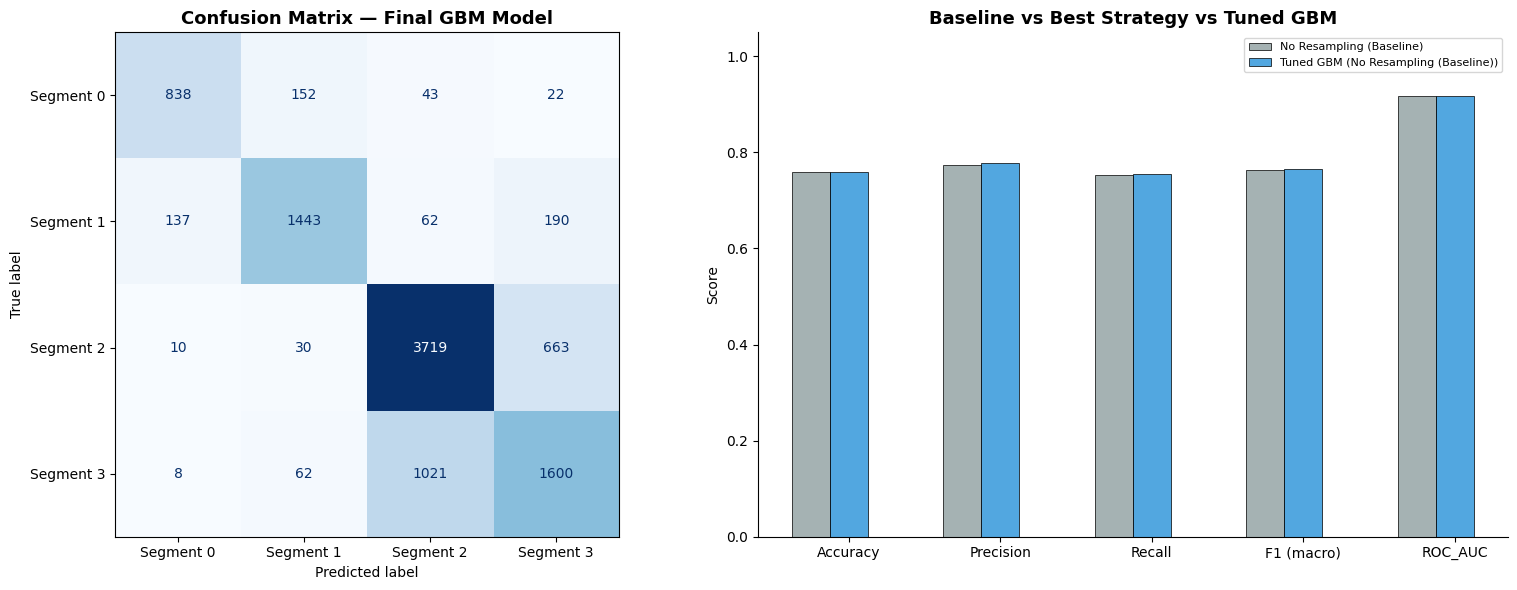

In [30]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Confusion matrix
disp = ConfusionMatrixDisplay.from_predictions(
    y_test, y_pred_final,
    display_labels=[class_labels[i] for i in range(4)],
    colorbar=False,
    ax=axes[0],
    cmap='Blues'
)
axes[0].set_title('Confusion Matrix — Final GBM Model', fontsize=13, fontweight='bold')

# Compare baseline vs tuned
compare_df = results_df[results_df['Strategy'].isin(['No Resampling (Baseline)', best_strategy_name])].copy()
tuned_row = pd.DataFrame([{
    'Strategy': f'Tuned GBM ({best_strategy_name})',
    'Accuracy': round(acc, 4),
    'Precision': round(prec, 4),
    'Recall': round(rec, 4),
    'F1 (macro)': round(f1, 4),
    'ROC_AUC': round(roc_auc, 4)
}])
compare_df = pd.concat([compare_df, tuned_row], ignore_index=True)

metrics_to_bar = ['Accuracy', 'Precision', 'Recall', 'F1 (macro)', 'ROC_AUC']
x = np.arange(len(metrics_to_bar))
width = 0.25
bar_colors = ['#95a5a6', '#3498db', '#e74c3c']

for i, (_, row) in enumerate(compare_df.iterrows()):
    vals = [row[m] for m in metrics_to_bar]
    bars = axes[1].bar(x + i*width, vals, width, label=row['Strategy'], color=bar_colors[i], alpha=0.85, edgecolor='black', linewidth=0.6)

axes[1].set_xticks(x + width)
axes[1].set_xticklabels(metrics_to_bar)
axes[1].set_title('Baseline vs Best Strategy vs Tuned GBM', fontsize=13, fontweight='bold')
axes[1].set_ylabel('Score')
axes[1].set_ylim(0, 1.05)
axes[1].legend(fontsize=8)
axes[1].spines['top'].set_visible(False)
axes[1].spines['right'].set_visible(False)

plt.tight_layout()
plt.show()